# Optimising an SMA Crossover Strategy

We previously tested a fixed SMA 50/200 crossover strategy, but that is only one possible parameter combination. In this notebook, we test many short/long SMA pairs to find the best historical performer on EUR/USD daily data.

This notebook is for educational purposes only and is not financial advice. The best historical parameters may be overfitted and may not work well in the future.


## 1. Import Libraries

We only need `pandas`, `numpy`, and `matplotlib` for this demo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')


## 2. Load EUR/USD Data

The notebook first tries to load `EURUSD.csv`. If the file is not available, it creates a synthetic EUR/USD series so the full optimization workflow can still run from top to bottom.


Synthetic EUR/USD fallback (CSV not found)

              price
Date               
2010-01-01 1.301784
2010-01-04 1.295706
2010-01-05 1.300089
2010-01-06 1.305603
2010-01-07 1.294191


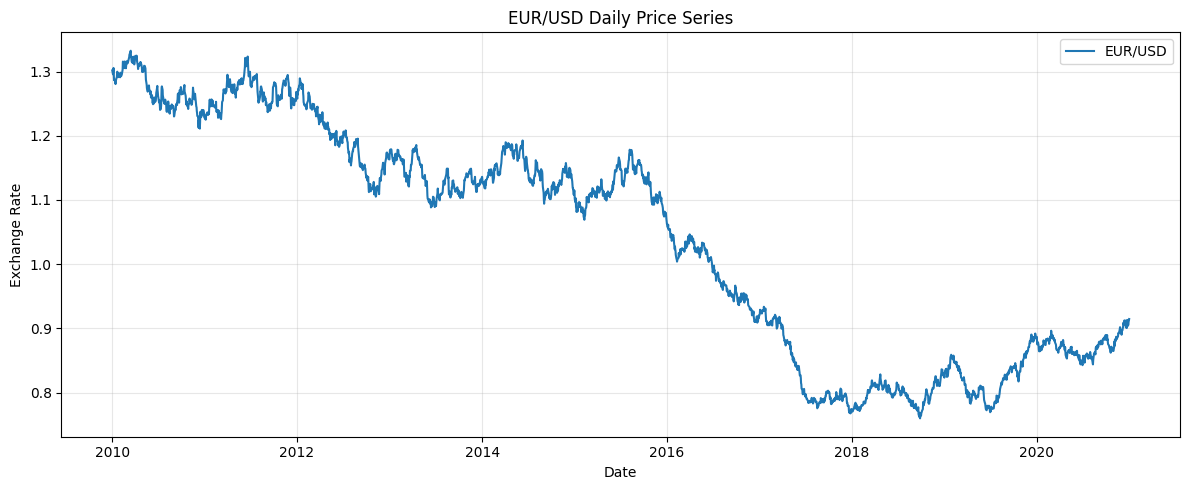

In [2]:
try:
    df = pd.read_csv("EURUSD.csv")
    data_source = "Loaded from EURUSD.csv"
except FileNotFoundError:
    try:
        df = pd.read_csv("eurusd.csv")
        data_source = "Loaded from eurusd.csv"
    except FileNotFoundError:
        rng = np.random.default_rng(42)
        trading_days = pd.date_range("2010-01-01", "2020-12-31", freq="B")
        log_moves = rng.normal(loc=0.0, scale=0.0045, size=len(trading_days))
        synthetic_price = 1.30 * np.exp(np.cumsum(log_moves))
        df = pd.DataFrame({"Date": trading_days, "price": synthetic_price})
        data_source = "Synthetic EUR/USD fallback (CSV not found)"

if "Date" not in df.columns:
    raise ValueError("The dataset must contain a Date column.")

if "price" not in df.columns:
    # Accept a few common price column names and rename them to price.
    for candidate in ["Close", "close", "Adj Close", "Adj_Close"]:
        if candidate in df.columns:
            df = df.rename(columns={candidate: "price"})
            break

if "price" not in df.columns:
    raise ValueError("No price column found. Expected price or a common close column.")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "price"]).set_index("Date").sort_index()

print(data_source)
print()
print(df.head())

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["price"], label="EUR/USD")
plt.title("EUR/USD Daily Price Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Create a Backtest Function

The `test_strategy()` function takes one SMA pair `(short_sma, long_sma)`, builds the trading rule, and returns the total strategy performance.

A result such as `1.28` means that an initial 1 unit of capital would have grown to 1.28 units over the backtest period.


In [3]:
def test_strategy(sma):
    """Test one SMA crossover pair and return total strategy performance."""
    short_sma, long_sma = sma
    data = df.copy()

    # Daily log returns for the EUR/USD benchmark.
    data["returns"] = np.log(data["price"] / data["price"].shift(1))

    # Build the two moving averages for this parameter pair.
    data["SMA_short"] = data["price"].rolling(short_sma).mean()
    data["SMA_long"] = data["price"].rolling(long_sma).mean()

    # Remove early rows where the moving averages are not yet available.
    data = data.dropna().copy()

    # Long when the short SMA is above the long SMA, short otherwise.
    data["position"] = np.where(data["SMA_short"] > data["SMA_long"], 1, -1)

    # Shift the position to avoid look-ahead bias.
    data["strategy"] = data["position"].shift(1) * data["returns"]
    data = data.dropna().copy()

    performance = np.exp(data["strategy"].sum())
    return round(performance, 6)


## 4. Test a Few SMA Combinations Manually

Before running the full optimization, it is useful to test a few parameter pairs by hand and confirm that the function behaves as expected.


In [4]:
manual_tests = {
    "SMA 50 / 200": test_strategy((50, 200)),
    "SMA 75 / 150": test_strategy((75, 150)),
    "SMA 25 / 252": test_strategy((25, 252)),
}

for label, result in manual_tests.items():
    print(f"{label}: {result:.6f}")


SMA 50 / 200: 0.967619
SMA 75 / 150: 1.013237
SMA 25 / 252: 0.973316


## 5. Define Optimization Ranges

We now search across many SMA combinations. The long SMA range runs up to 252 trading days, which is roughly one trading year.


In [5]:
sma_short_range = range(10, 51)
sma_long_range = range(100, 253)

print("Number of short SMA candidates:", len(range(10, 51)))
print("Number of long SMA candidates:", len(range(100, 253)))


Number of short SMA candidates: 41
Number of long SMA candidates: 153


## 6. Optimise the SMA Combinations

We test every valid pair where the short SMA is smaller than the long SMA, store the results, and rank them by historical performance.


In [6]:
results = []

for short_sma in sma_short_range:
    for long_sma in sma_long_range:
        if short_sma < long_sma:
            performance = test_strategy((short_sma, long_sma))
            results.append((short_sma, long_sma, performance))

results_df = pd.DataFrame(results, columns=["SMA_short", "SMA_long", "performance"])
results_df = results_df.sort_values("performance", ascending=False).reset_index(drop=True)

print("Top 10 SMA combinations:")
print(results_df.head(10))


Top 10 SMA combinations:
   SMA_short  SMA_long  performance
0         35       102     1.445283
1         36       100     1.428852
2         35       101     1.426601
3         35       103     1.415716
4         35       100     1.415401
5         36       101     1.402990
6         34       101     1.379175
7         34       102     1.360428
8         36       102     1.358520
9         38       102     1.357251


## 7. Find the Best SMA Strategy

Once the full search is complete, we can read the best-performing parameter combination directly from the sorted results table.


In [7]:
best_result = results_df.iloc[0]
best_short_sma = int(best_result["SMA_short"])
best_long_sma = int(best_result["SMA_long"])
best_performance = best_result["performance"]

print(f"Best short SMA: {best_short_sma}")
print(f"Best long SMA: {best_long_sma}")
print(f"Best performance: {best_performance:.6f}")


Best short SMA: 35
Best long SMA: 102
Best performance: 1.445283


## 8. Visualise the Optimization Results

A heatmap helps us see where strong and weak parameter regions appear. The x-axis is the long SMA, the y-axis is the short SMA, and the colour shows total strategy performance.


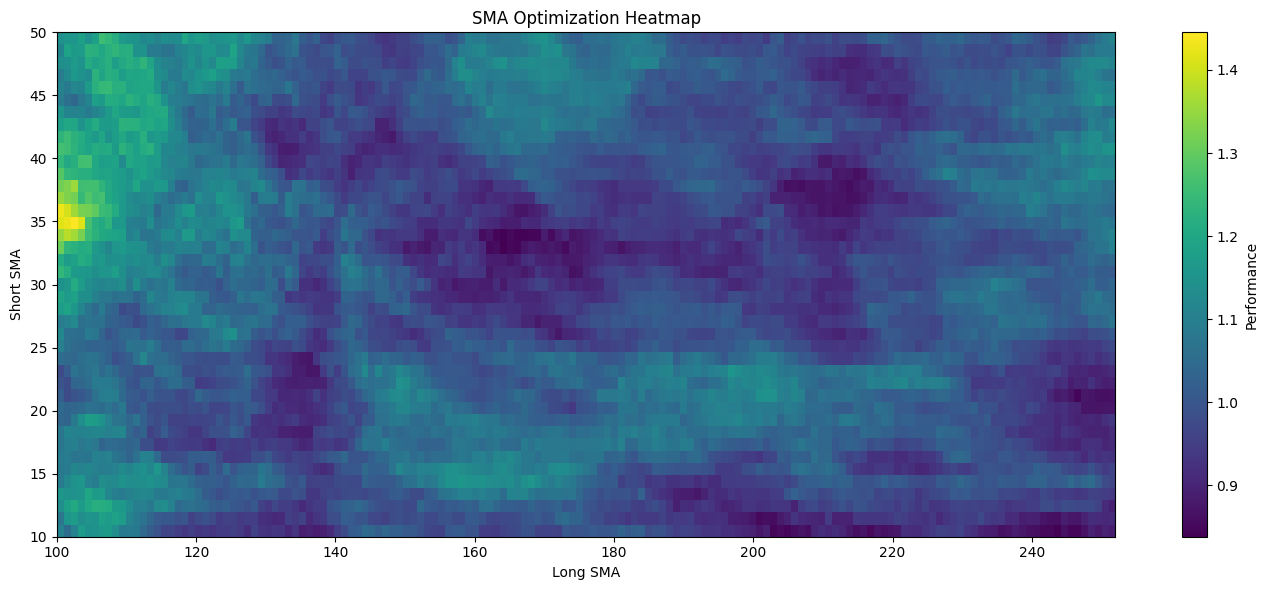

In [8]:
heatmap_data = results_df.pivot(index="SMA_short", columns="SMA_long", values="performance")

plt.figure(figsize=(14, 6))
image = plt.imshow(
    heatmap_data,
    aspect="auto",
    origin="lower",
    extent=[heatmap_data.columns.min(), heatmap_data.columns.max(), heatmap_data.index.min(), heatmap_data.index.max()]
)
plt.colorbar(image, label="Performance")
plt.title("SMA Optimization Heatmap")
plt.xlabel("Long SMA")
plt.ylabel("Short SMA")
plt.tight_layout()
plt.show()


## 9. Run the Best Strategy Again

To inspect the best strategy properly, it helps to rebuild the full strategy DataFrame with cumulative buy-and-hold and cumulative strategy performance.


In [9]:
def build_strategy_dataframe(sma):
    """Return the full strategy DataFrame for a given SMA pair."""
    short_sma, long_sma = sma
    data = df.copy()

    data["returns"] = np.log(data["price"] / data["price"].shift(1))
    data["SMA_short"] = data["price"].rolling(short_sma).mean()
    data["SMA_long"] = data["price"].rolling(long_sma).mean()
    data = data.dropna().copy()

    data["position"] = np.where(data["SMA_short"] > data["SMA_long"], 1, -1)
    data["strategy"] = data["position"].shift(1) * data["returns"]
    data = data.dropna().copy()

    data["creturns"] = data["returns"].cumsum().apply(np.exp)
    data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)

    return data[["price", "returns", "SMA_short", "SMA_long", "position", "strategy", "creturns", "cstrategy"]]


best_strategy = build_strategy_dataframe((best_short_sma, best_long_sma))
best_strategy.head()


,price,returns,SMA_short,SMA_long,position,strategy,creturns,cstrategy
Date,,,,,,,,
2010-05-25,1.274157,-0.001603,1.300875,1.304958,-1,0.001603,0.998398,1.001604
2010-05-26,1.278392,0.003319,1.299549,1.304788,-1,-0.003319,1.001717,0.998286
2010-05-27,1.273033,-0.004201,1.298102,1.304523,-1,0.004201,0.997517,1.002489
2010-05-28,1.271856,-0.000924,1.296839,1.304192,-1,0.000924,0.996596,1.003416
2010-05-31,1.266431,-0.004275,1.295611,1.303920,-1,0.004275,0.992344,1.007715


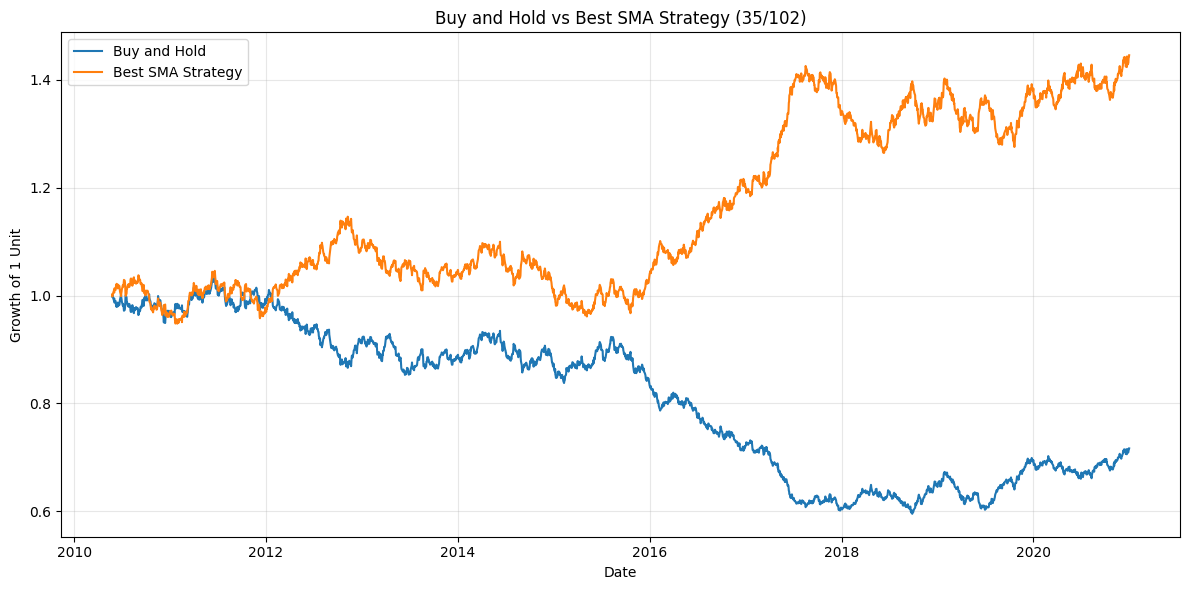

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(best_strategy.index, best_strategy["creturns"], label="Buy and Hold")
plt.plot(best_strategy.index, best_strategy["cstrategy"], label="Best SMA Strategy")
plt.title(f"Buy and Hold vs Best SMA Strategy ({best_short_sma}/{best_long_sma})")
plt.xlabel("Date")
plt.ylabel("Growth of 1 Unit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Final Interpretation

This optimization finds the best historical SMA pair in the tested range. That optimised pair may outperform a fixed SMA 50/200 rule, but that does **not** mean it will continue to work in the future.

Testing many parameter combinations increases the risk of overfitting, because we may end up choosing the pair that happened to fit noise in the historical sample. A more realistic workflow should include train/test splits, transaction costs, spreads, slippage, and some form of forward testing.
